In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols]
y_test_pca = test_df_pca["target"]

In [5]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, accuracy_score

In [6]:
#First train with the ANOVA-10 features

In [7]:
et = ExtraTreesClassifier(random_state=42, n_jobs=-1)
et.fit(x_train, y_train)

et_preds = et.predict(x_test)
et_accuracy = accuracy_score(y_test, et_preds)

print("Extra Trees Accuracy:", et_accuracy)
print(classification_report(y_test, et_preds))

Extra Trees Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.95      0.81      0.88        74
           1       0.88      0.93      0.91        72
           2       0.84      0.92      0.88        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [8]:
#Try with PCA features

In [9]:
et_pca = ExtraTreesClassifier(random_state=42, n_jobs=-1)
et_pca.fit(x_train_pca, y_train_pca)

et_preds_pca = et_pca.predict(x_test_pca)
et_accuracy_pca = accuracy_score(y_test_pca, et_preds_pca)

print("Extra Trees Accuracy (PCA):", et_accuracy_pca)
print(classification_report(y_test_pca, et_preds_pca))

Extra Trees Accuracy (PCA): 0.8772727272727273
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        74
           1       0.84      0.90      0.87        72
           2       0.91      0.86      0.89        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [ ]:
#Compare the two accuracies and pick the better feature set ANOVA top 10
#Moving to hyperparameter tuning for ANOVA top 10

In [11]:
from sklearn.model_selection import GridSearchCV

In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"],
}

grid_et = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_et.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,ExtraTreesCla...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [20]:
best_et = grid_et.best_estimator_

print("Best ET parameters:", grid_et.best_params_)
print("Best ET CV accuracy:", grid_et.best_score_)

Best ET parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best ET CV accuracy: 0.8863636363636364


In [21]:
tuned_et_preds = best_et.predict(x_test)
tuned_et_accuracy = accuracy_score(y_test, tuned_et_preds)

print("Tuned ET Test Accuracy:", tuned_et_accuracy)
print(classification_report(y_test, tuned_et_preds))

Tuned ET Test Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        74
           1       0.94      0.90      0.92        72
           2       0.81      0.93      0.87        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [22]:
tuned_et_preds_train = best_et.predict(x_train)
print("Tuned ET Train Accuracy:", accuracy_score(y_train, tuned_et_preds_train))

Tuned ET Train Accuracy: 0.9545454545454546


In [23]:
import joblib
joblib.dump(best_et, "../results/model_trained_files/extra_trees_model.pkl")

['../results/model_trained_files/extra_trees_model.pkl']

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

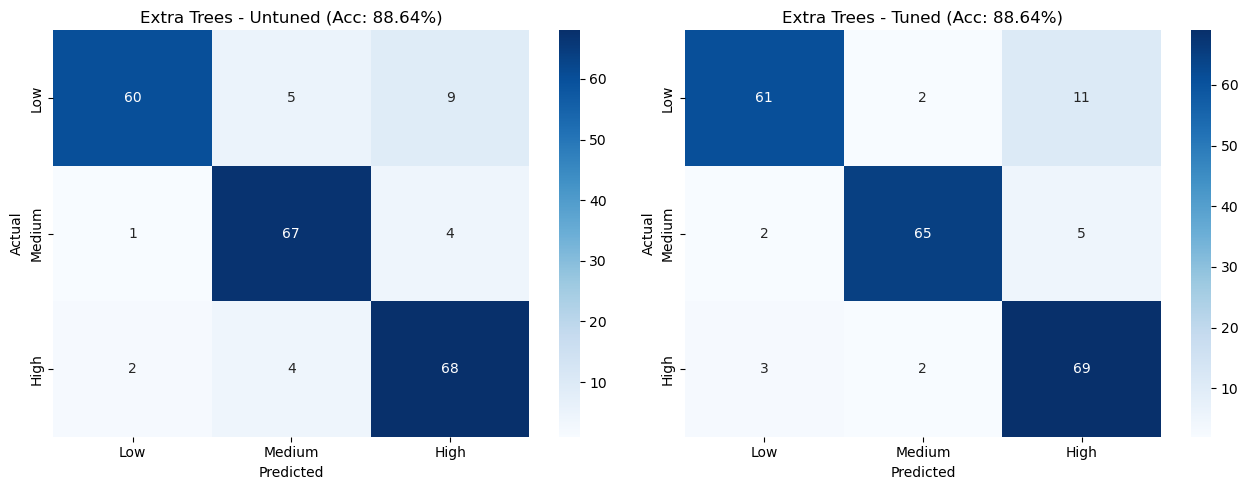

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test, tuned_et_preds)

cm_unt = confusion_matrix(y_test, et_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"Extra Trees - Untuned (Acc: {et_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"Extra Trees - Tuned (Acc: {tuned_et_accuracy:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/et_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()